In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Load Clean Data and Split

In [2]:
# 1. Load the CLEANED data from Notebook 1
df = pd.read_csv('processed_sleep_data.csv')

In [3]:
# 2. Split into Features (X) and Target (y)
X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']

In [4]:
# 3. Split into Train (80%) and Test (20%)
# stratify=y keeps the same ratio of disorders in training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
# Class names mapping from the previous notebook's encoder
class_names = ['Insomnia', 'None', 'Sleep Apnea']
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (299, 12)
Testing data shape: (75, 12)


Random Forest

In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
y_pred_rf = rf.predict(X_test)

Evaluation

In [8]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

Accuracy: 0.9600

Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.88      0.93      0.90        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.94      0.94      0.94        16

    accuracy                           0.96        75
   macro avg       0.94      0.95      0.94        75
weighted avg       0.96      0.96      0.96        75



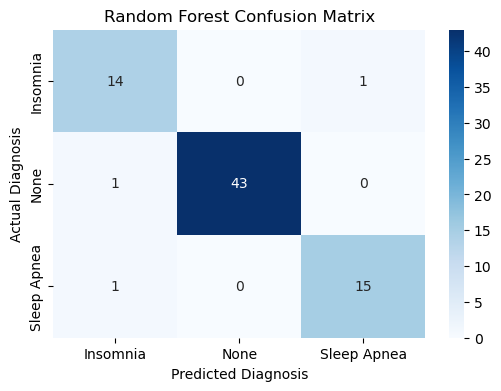

In [9]:
# Generate a Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()

Feature Importance

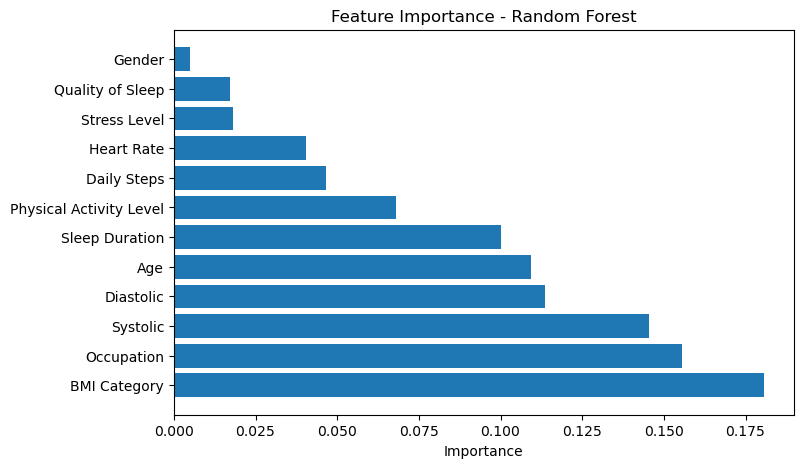

In [10]:
# Feature importance
feature_importance = rf.feature_importances_
features = X.columns
imp_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(imp_df['Feature'], imp_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.show()

Summary

The Random Forest model was able to classify sleep disorders with good accuracy. The difference between training and testing accuracy is small, which shows that the model is not heavily overfitting. From the feature importance results, factors like sleep duration and stress level have a higher impact on prediction. Overall, Random Forest gives more stable results compared to a single decision tree.

Save Model

In [11]:
# Export the trained model
joblib.dump(rf, 'random_forest_model.pkl')
print("✓ Model saved as 'random_forest_model.pkl'")

✓ Model saved as 'random_forest_model.pkl'
